# 3D shot map — FC Bayern München (Bayern vs Hamburg)

3D shot map styled after [StatsBomb 3D shot maps in Plotly](https://python.plainenglish.io/visualizing-statsbomb-soccer-data-in-3d-with-streamlit-ff94c5e711f0): green pitch plane (`zaxis` background), white box markings, **parabolic shot arcs** `z = z₀ + (z₁−z₀)·t·(2−t)`, camera `eye=(0, 3, 0.7)`, `aspectmode='data'`. Dominant goal end only (13 shots).

Data: `derived/shooting1_v3_all_matches/tracking_samples.csv`

In [1]:
from pathlib import Path
import pandas as pd
from aws_football.bsq_shot_trajectory_3d import (
    load_shot_trajectories,
    plot_3d_shot_map,
    display_matplotlib_figure,
    display_shot_map_interactive,
    write_shot_map_html,
    resolve_tracking_samples_path,
)

MATCH = "Bayern_Hamburg"
TEAM = "Bayern"
tracking_path = resolve_tracking_samples_path()
print("tracking:", tracking_path)

shots = pd.read_csv("../reference_outputs/shots.csv")
bayern = shots[(shots.match_folder == MATCH) & shots.team_name.str.contains(TEAM, na=False)]
bayern[["player_name", "shot_result", "x", "y", "xg"]].sort_values("shot_result")

tracking: /Users/tayyabkhan/Downloads/aws/derived/shooting1_v3_all_matches/tracking_samples.csv


,player_name,shot_result,x,y,xg
0,Michael Olise,blockedShot,-44.30,21.51,0.0445
11,Serge Gnabry,blockedShot,-42.91,-15.00,0.0424
17,K. Laimer,blockedShot,-41.38,11.75,0.0695
28,Michael Olise,blockedShot,35.61,12.69,0.0278
3,Michael Olise,savedShot,-35.44,-1.25,0.1239
5,Luis Díaz,savedShot,-51.70,-8.14,0.0939
13,Luis Díaz,savedShot,-13.74,2.94,0.0265
15,Michael Olise,savedShot,-34.72,1.95,0.0938
19,Michael Olise,savedShot,33.87,-12.12,0.0267
21,L. Karl,savedShot,29.20,-11.73,0.0295


In [2]:
trajectories = load_shot_trajectories(
    match_folder=MATCH,
    team_name=TEAM,
    tracking_path=tracking_path,
)
print(f"{len(trajectories)} shots with flight tracks (of {len(bayern)} Bayern shots in match)")

21 shots with flight tracks (of 21 Bayern shots in match)


saved preview: /Users/tayyabkhan/Downloads/aws/final-repo/outputs/shot_map_bayern_hamburg_preview.png


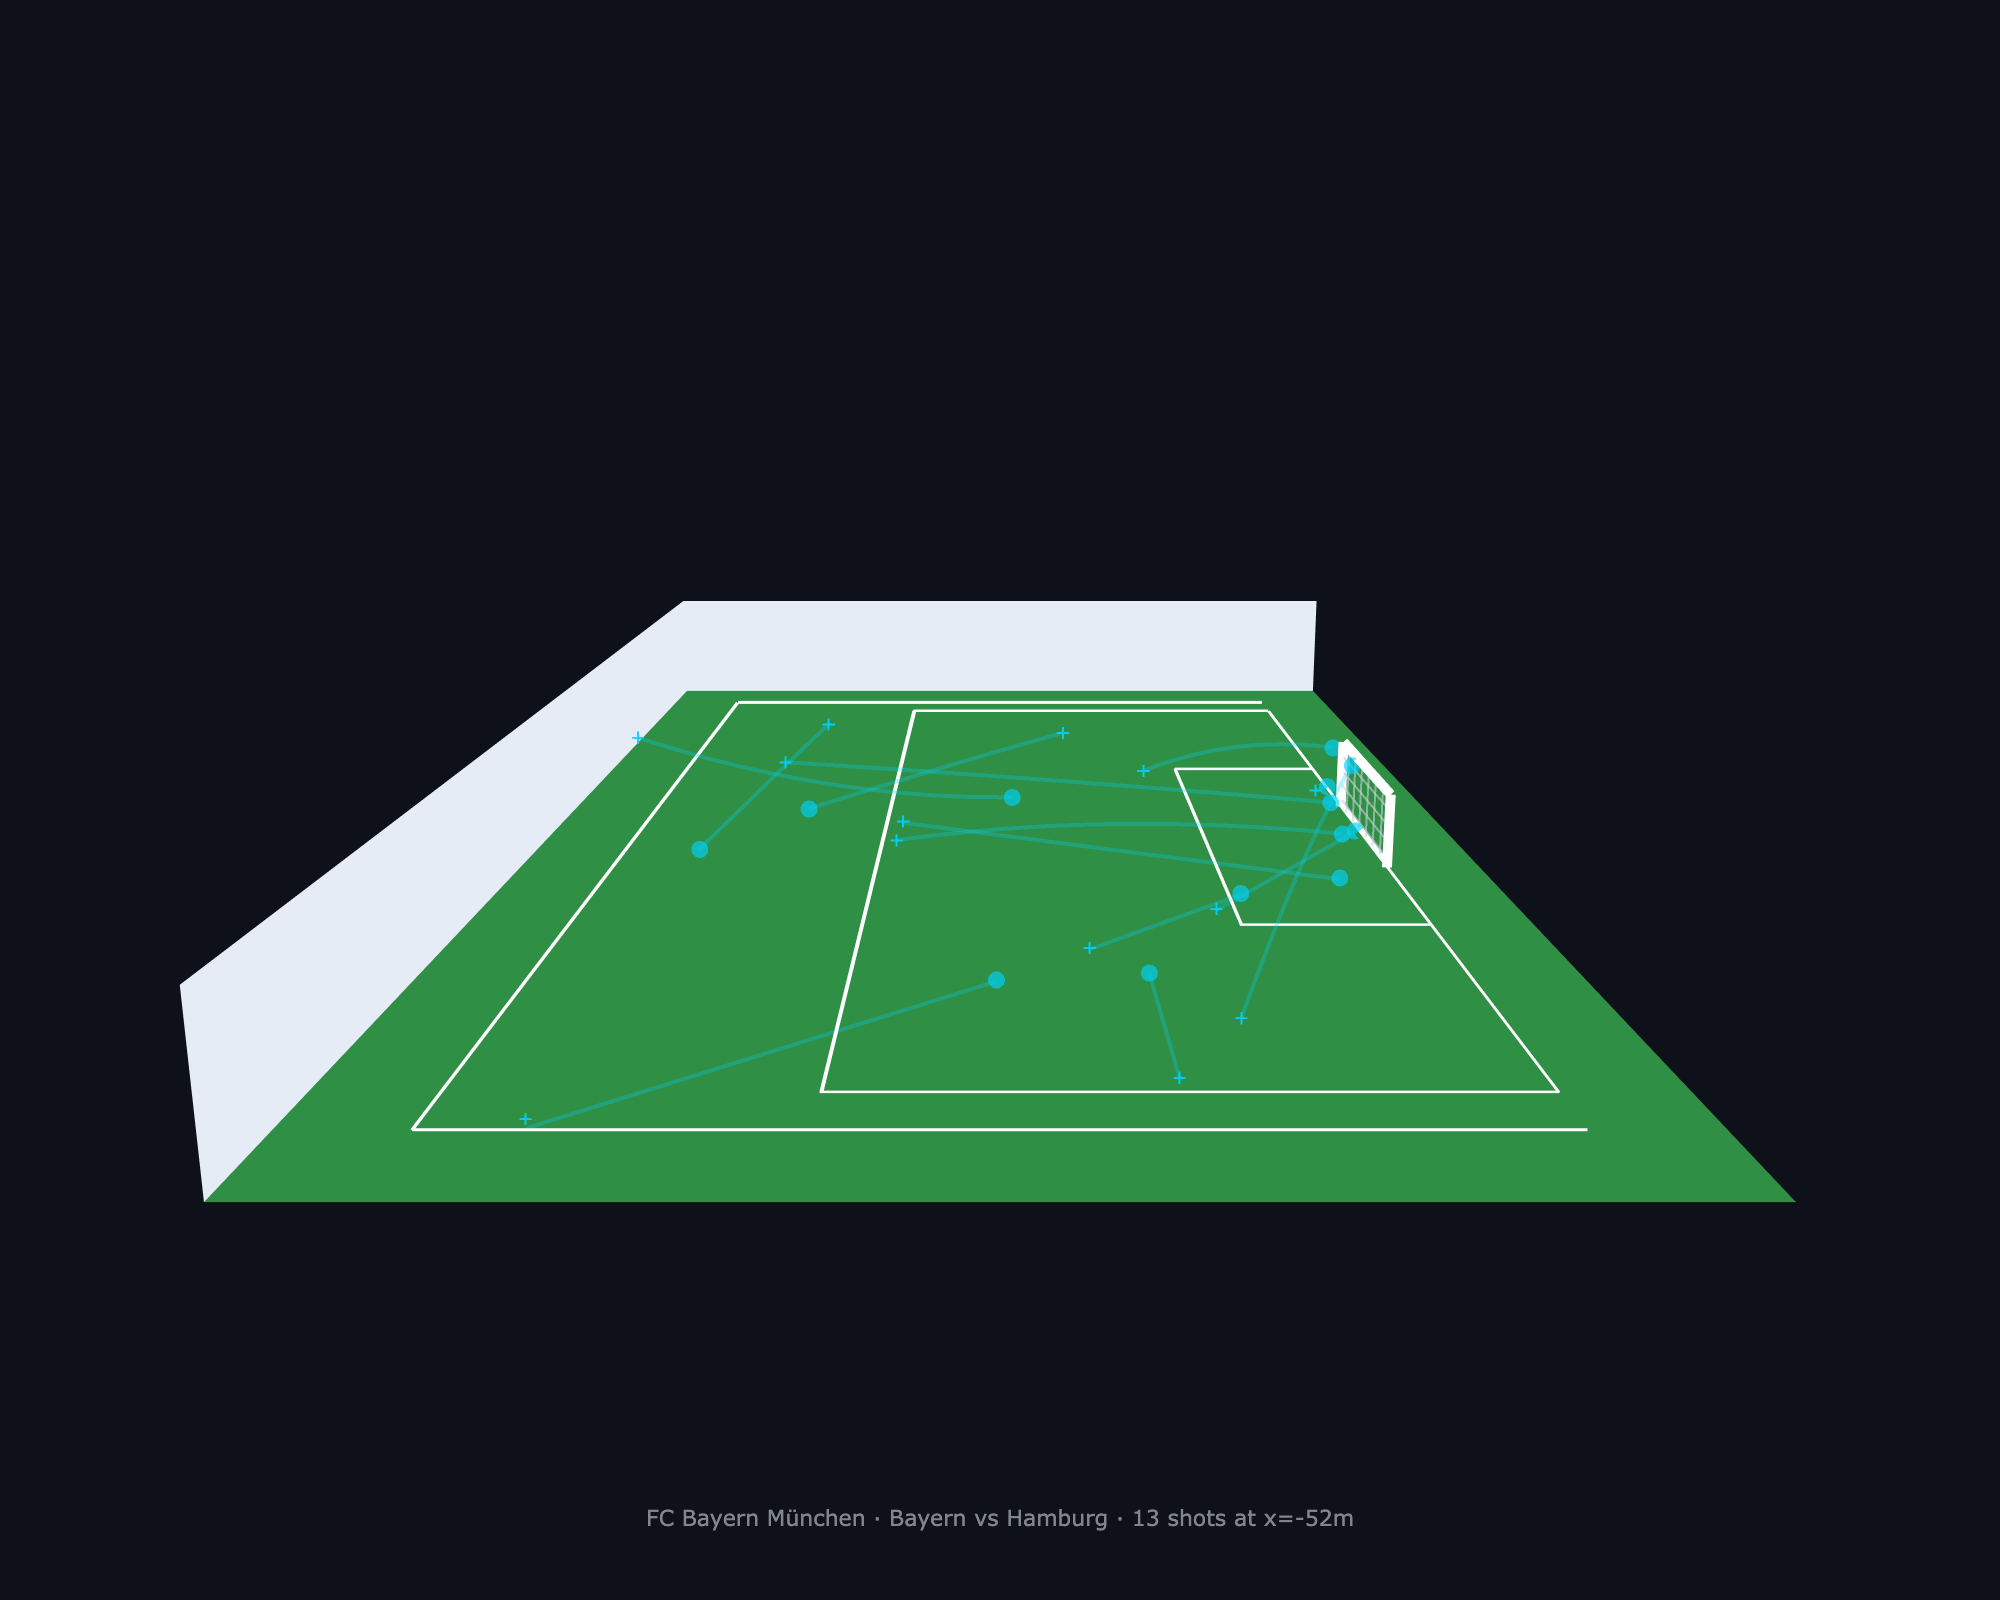

In [3]:
import plotly.io as pio
from aws_football.bsq_shot_trajectory_3d import filter_trajectories_by_goal

shown, goal_x = filter_trajectories_by_goal(trajectories, goal="dominant")
fig = plot_3d_shot_map(
    trajectories,
    goal_filter="dominant",
    subtitle=f"FC Bayern München · Bayern vs Hamburg · {len(shown)} shots at x={goal_x:.0f}m",
)
preview_path = Path("../../outputs/shot_map_bayern_hamburg_preview.png")
preview_path.parent.mkdir(parents=True, exist_ok=True)
pio.write_image(fig, preview_path, width=1000, height=820, scale=2)
print(f"saved preview: {preview_path.resolve()}")
display_matplotlib_figure(fig, dpi=180)

### Interactive 3D (orbit / zoom)

Same figure as above, exported as HTML — drag to rotate, scroll to zoom (like the [StatsBomb Streamlit 3D app](https://3dsoccervisualizer.streamlit.app/)). Saved to `outputs/shot_map_bayern_hamburg.html` for opening in a browser.

In [4]:
html_path = Path("../../outputs/shot_map_bayern_hamburg.html")
saved_html = display_shot_map_interactive(fig, html_path=html_path, iframe_height=820)
print(f"Interactive map: {saved_html}")
print("Open that file in a browser if the cell below does not render.")

Interactive map: /Users/tayyabkhan/Downloads/aws/final-repo/outputs/shot_map_bayern_hamburg.html
Open that file in a browser if the cell below does not render.


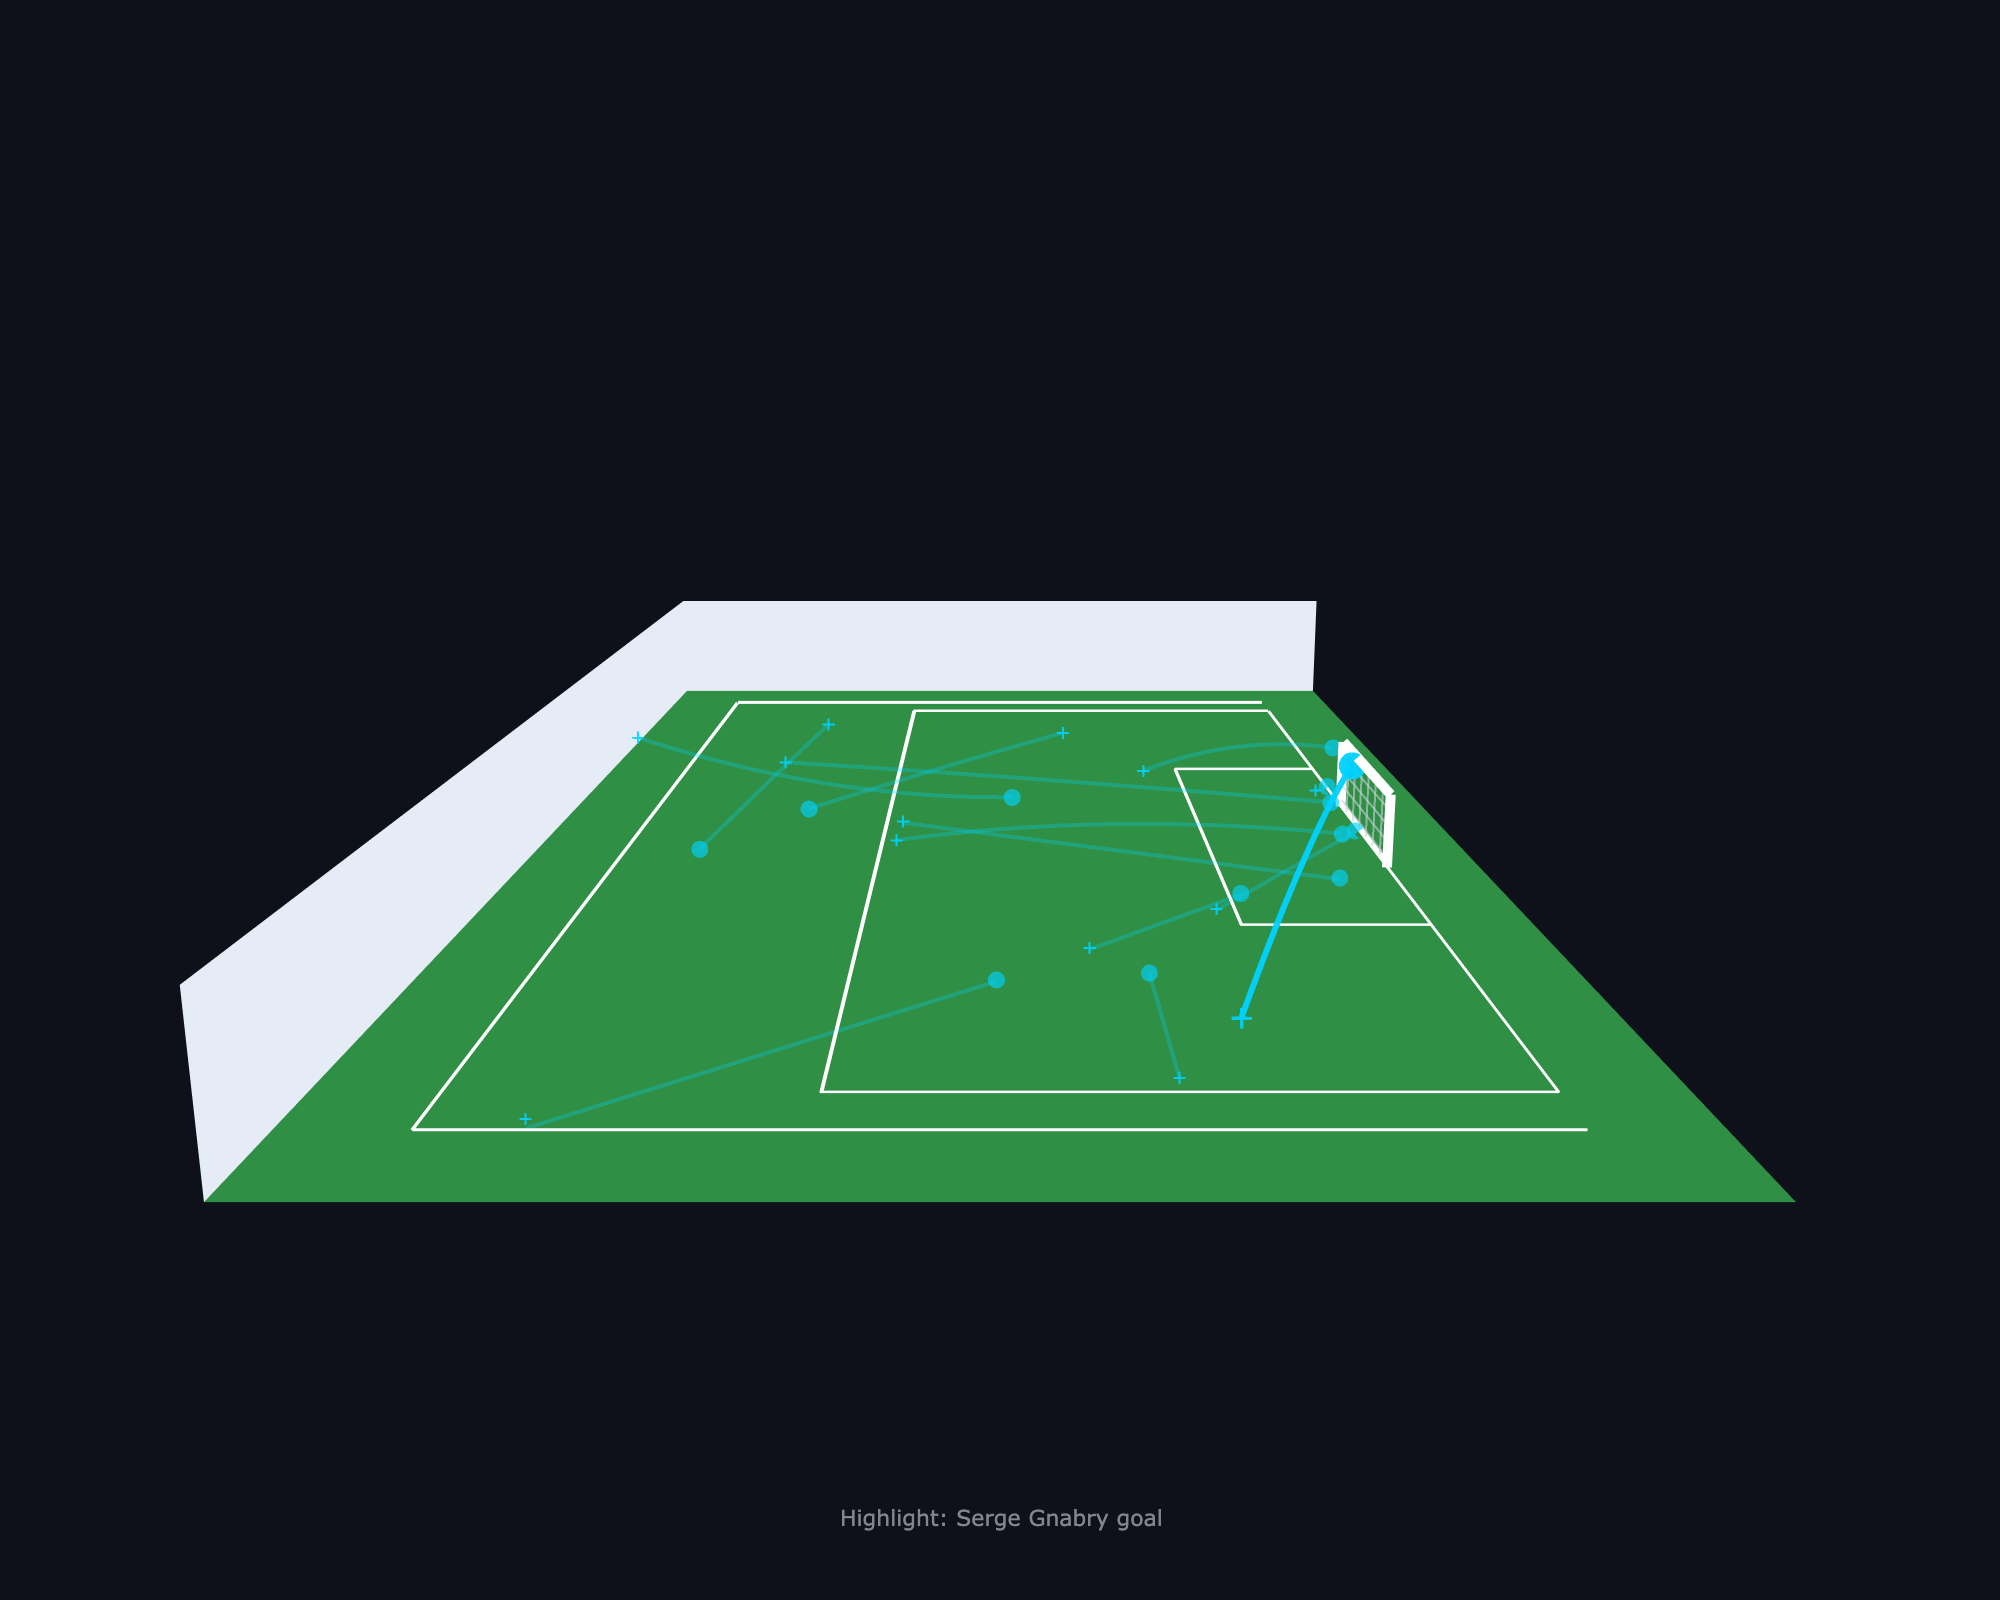

In [5]:
# Optional: emphasise one goal (Serge Gnabry)
fig_goal = plot_3d_shot_map(
    trajectories,
    goal_filter="dominant",
    highlight_event_id=18902400000048,
    subtitle="Highlight: Serge Gnabry goal",
)
display_matplotlib_figure(fig_goal, dpi=180)